In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
prices = pd.read_parquet("../data/processed/stock_prices_clean.parquet")

## 1. Dataset overview

## 2. Average trading volume

<Axes: title={'center': 'Average Daily Trading Volume by Asset'}, xlabel='ticker'>

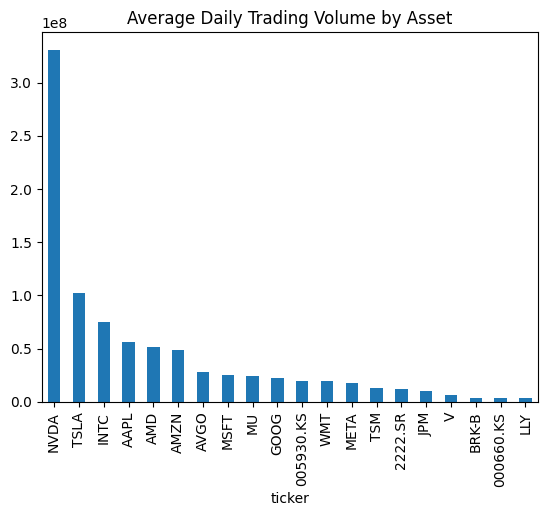

In [3]:
average_volume = (
    prices.groupby("ticker")["volume"]
    .mean()
    .sort_values(ascending=False)
)
average_volume.plot(
    kind="bar",
    title="Average Daily Trading Volume by Asset")

## 3. Cumulative returns

Which assets performed best over the entire observation period?

In [4]:
pivot_prices = prices.pivot(
    index="date",
    columns="ticker",
    values="close"
)

C:\Users\elton\AppData\Local\Temp\ipykernel_7612\16178406.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = pivot_prices.pct_change()


<Axes: title={'center': 'Cumulative Returns'}, xlabel='date'>

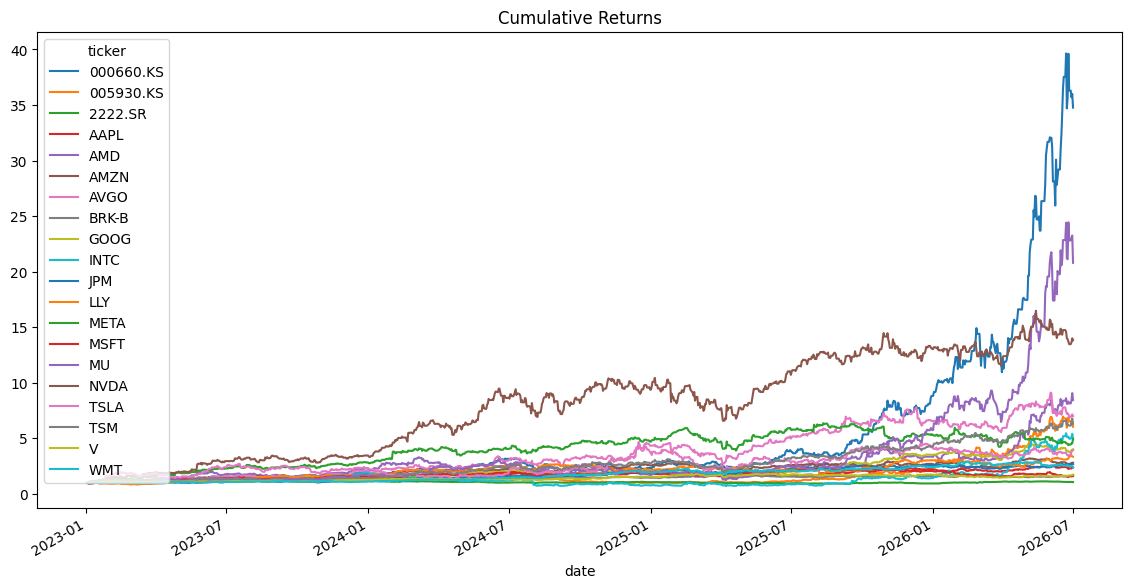

In [5]:
returns = pivot_prices.pct_change()

cumulative_returns = (
    1 + returns
).cumprod()

cumulative_returns.plot(
    figsize=(14,7),
    title="Cumulative Returns"
)

## 4. Distribution of daily returns

<Axes: xlabel='ticker'>

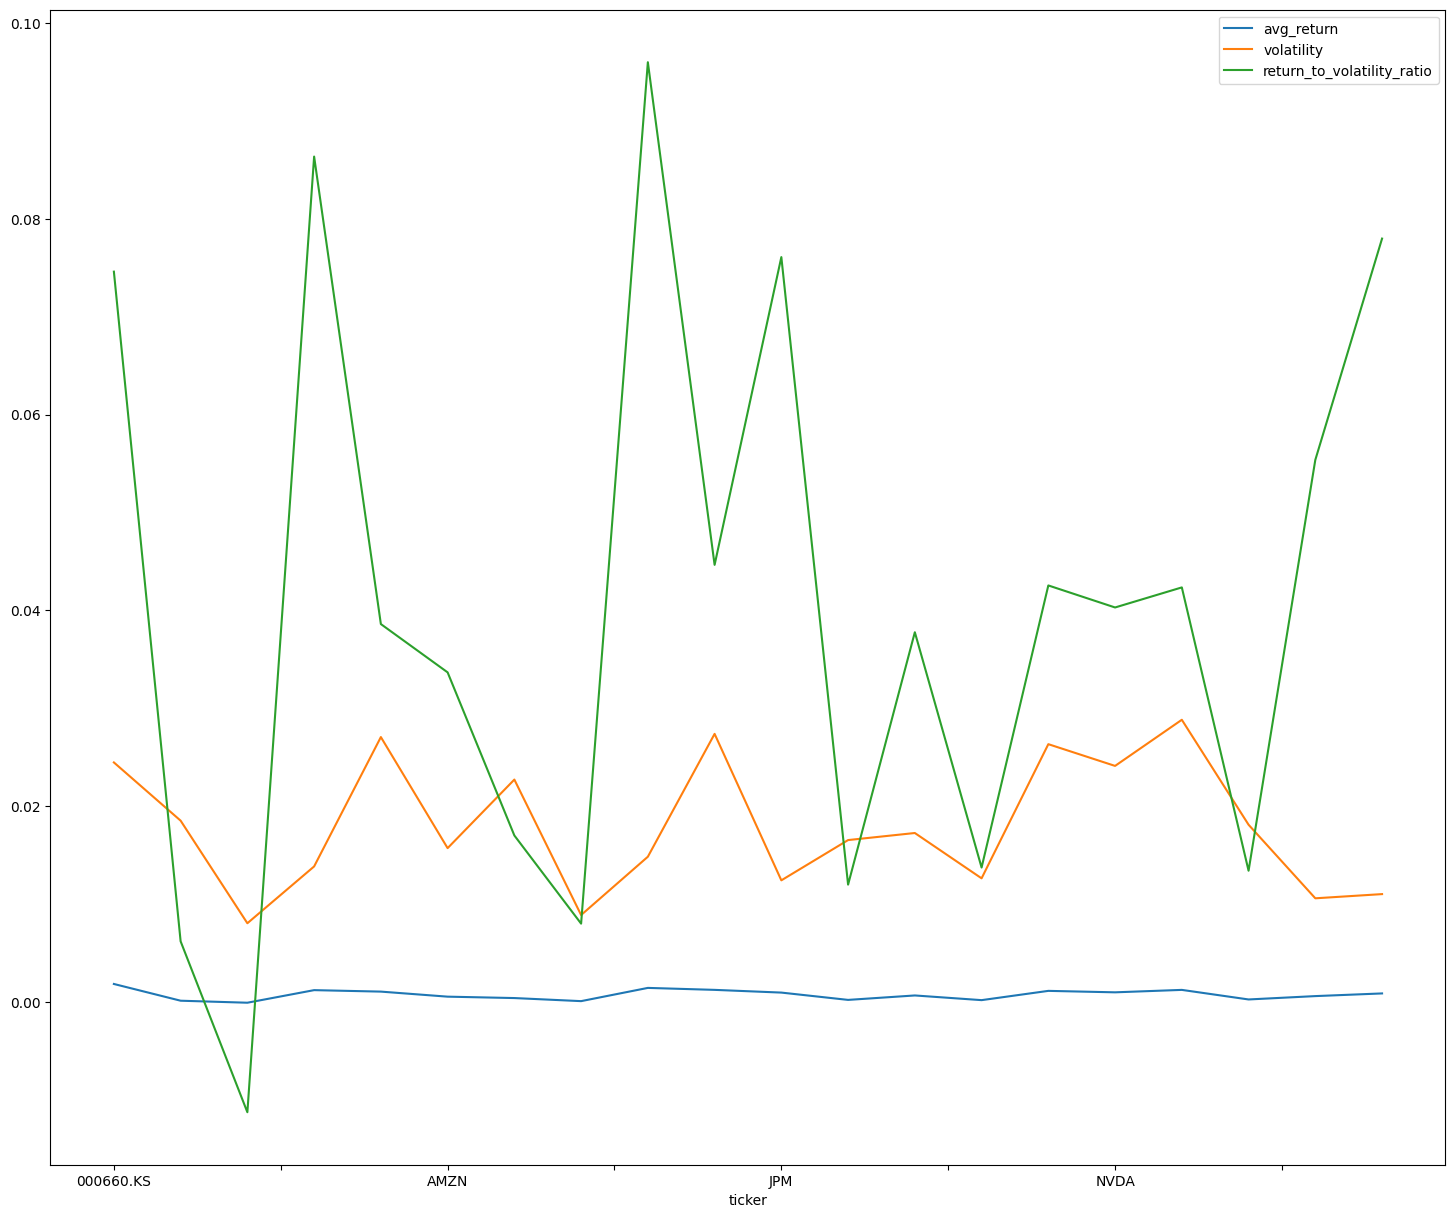

In [6]:
performance = (
    prices.groupby("ticker")
    .agg(
        avg_return=("daily_return","mean"),
        volatility=("daily_return","std")
    )
)

performance["return_to_volatility_ratio"] = (
    performance["avg_return"] /
    performance["volatility"]
)

performance.plot(figsize=(18,15))

## 5. Return boxplots

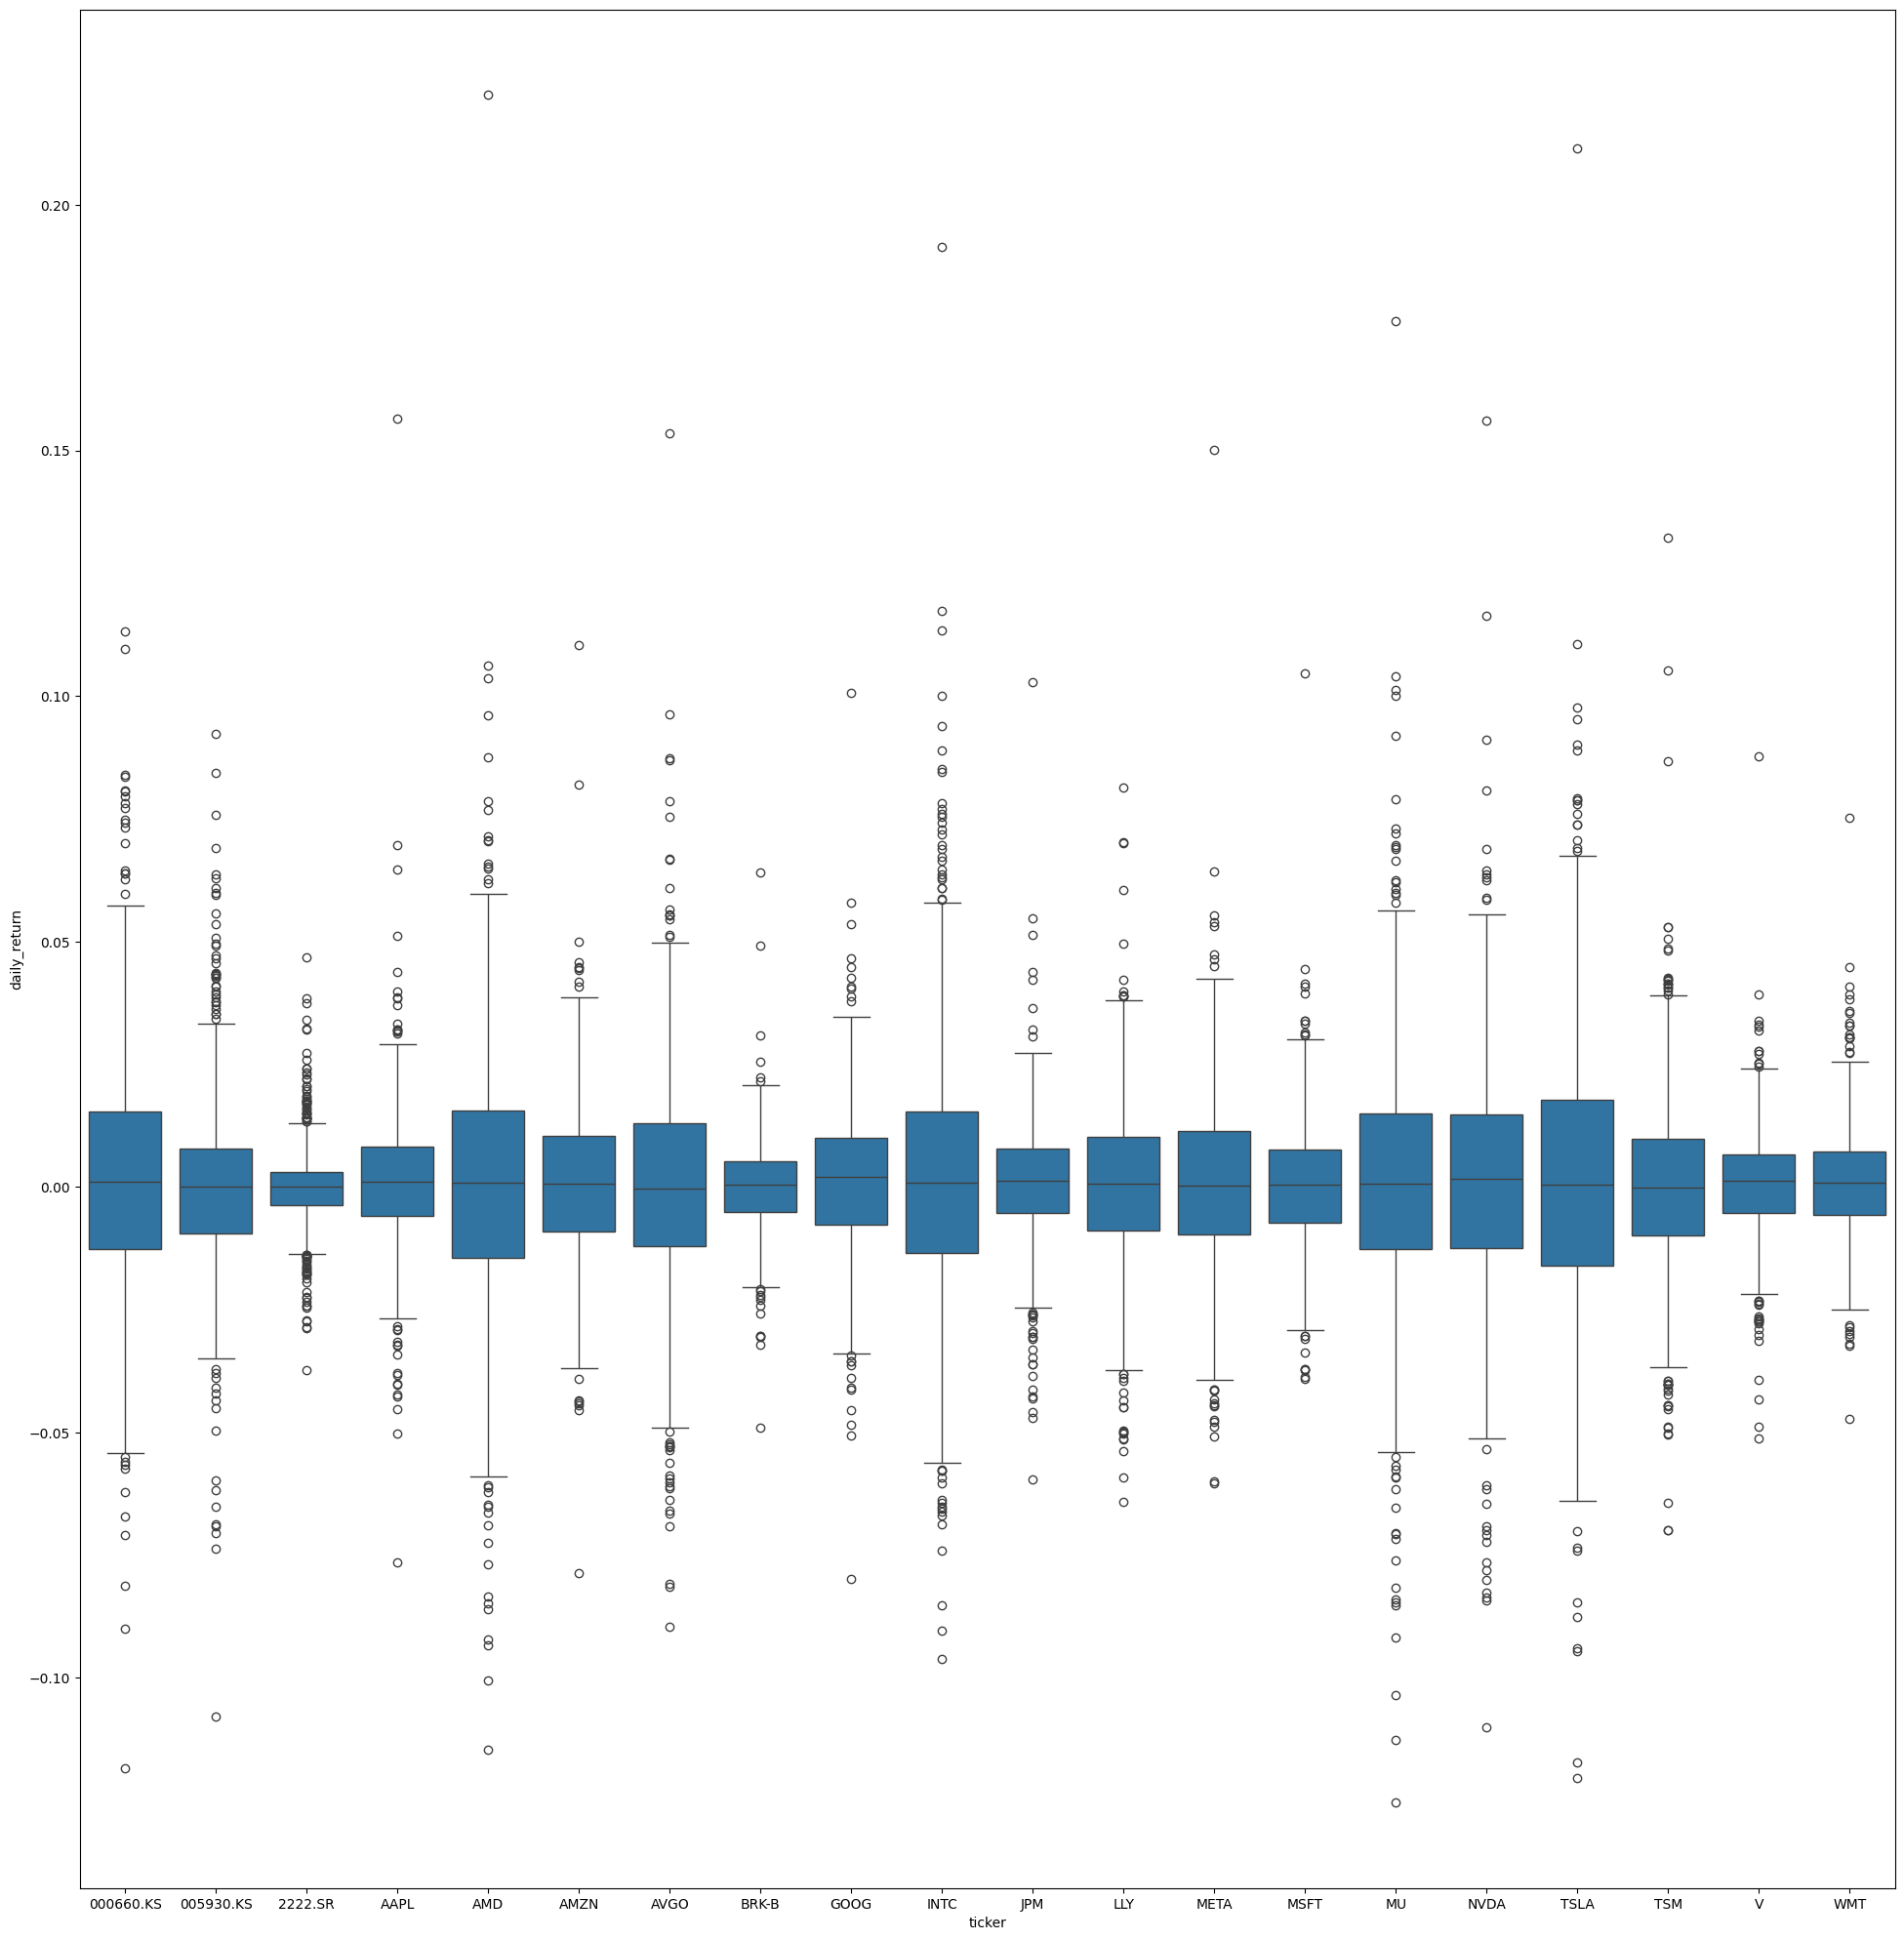

In [7]:
fig, ax = plt.subplots(figsize=(24, 25))
sns.boxplot(
    data=prices,
    x="ticker",
    y="daily_return"
)
plt.show()

## 6. Volatility ranking

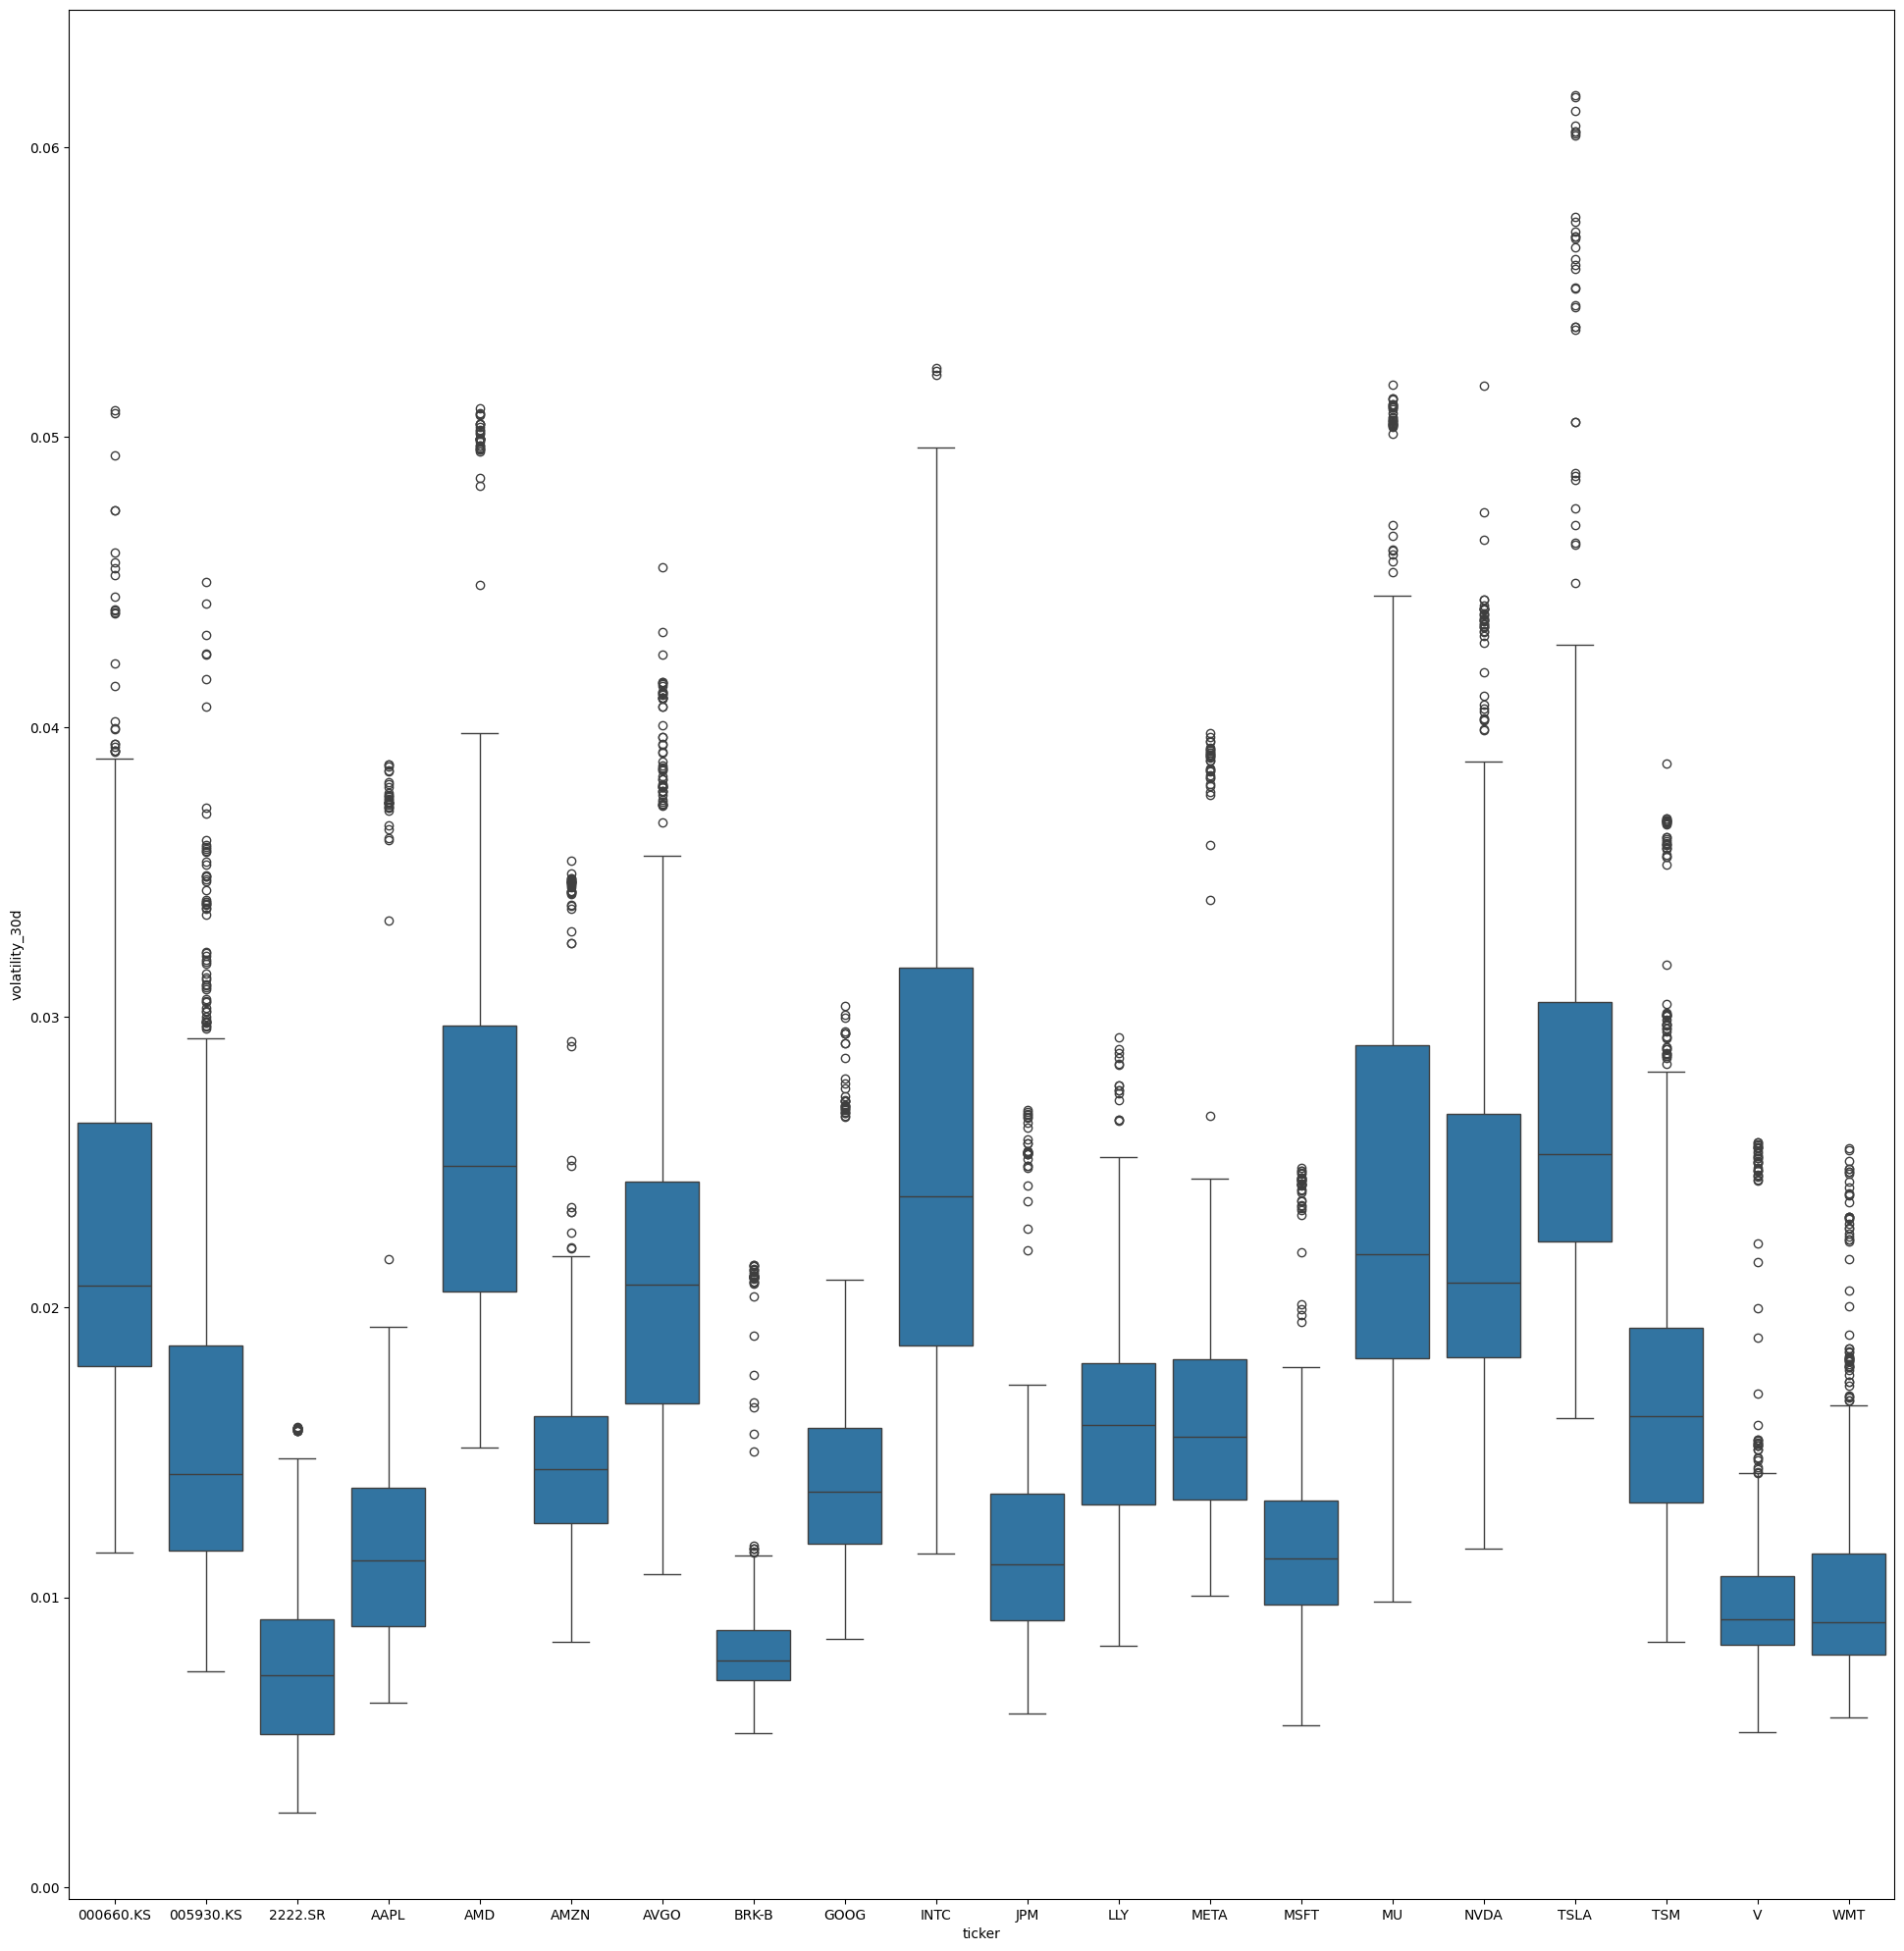

In [8]:
fig, ax = plt.subplots(figsize=(24, 25))
sns.boxplot(
    data=prices,
    x="ticker",
    y="volatility_30d"
)
plt.show()

NVDA exhibited the highest average rolling volatility, suggesting substantially larger day-to-day price fluctuations than the remaining assets.

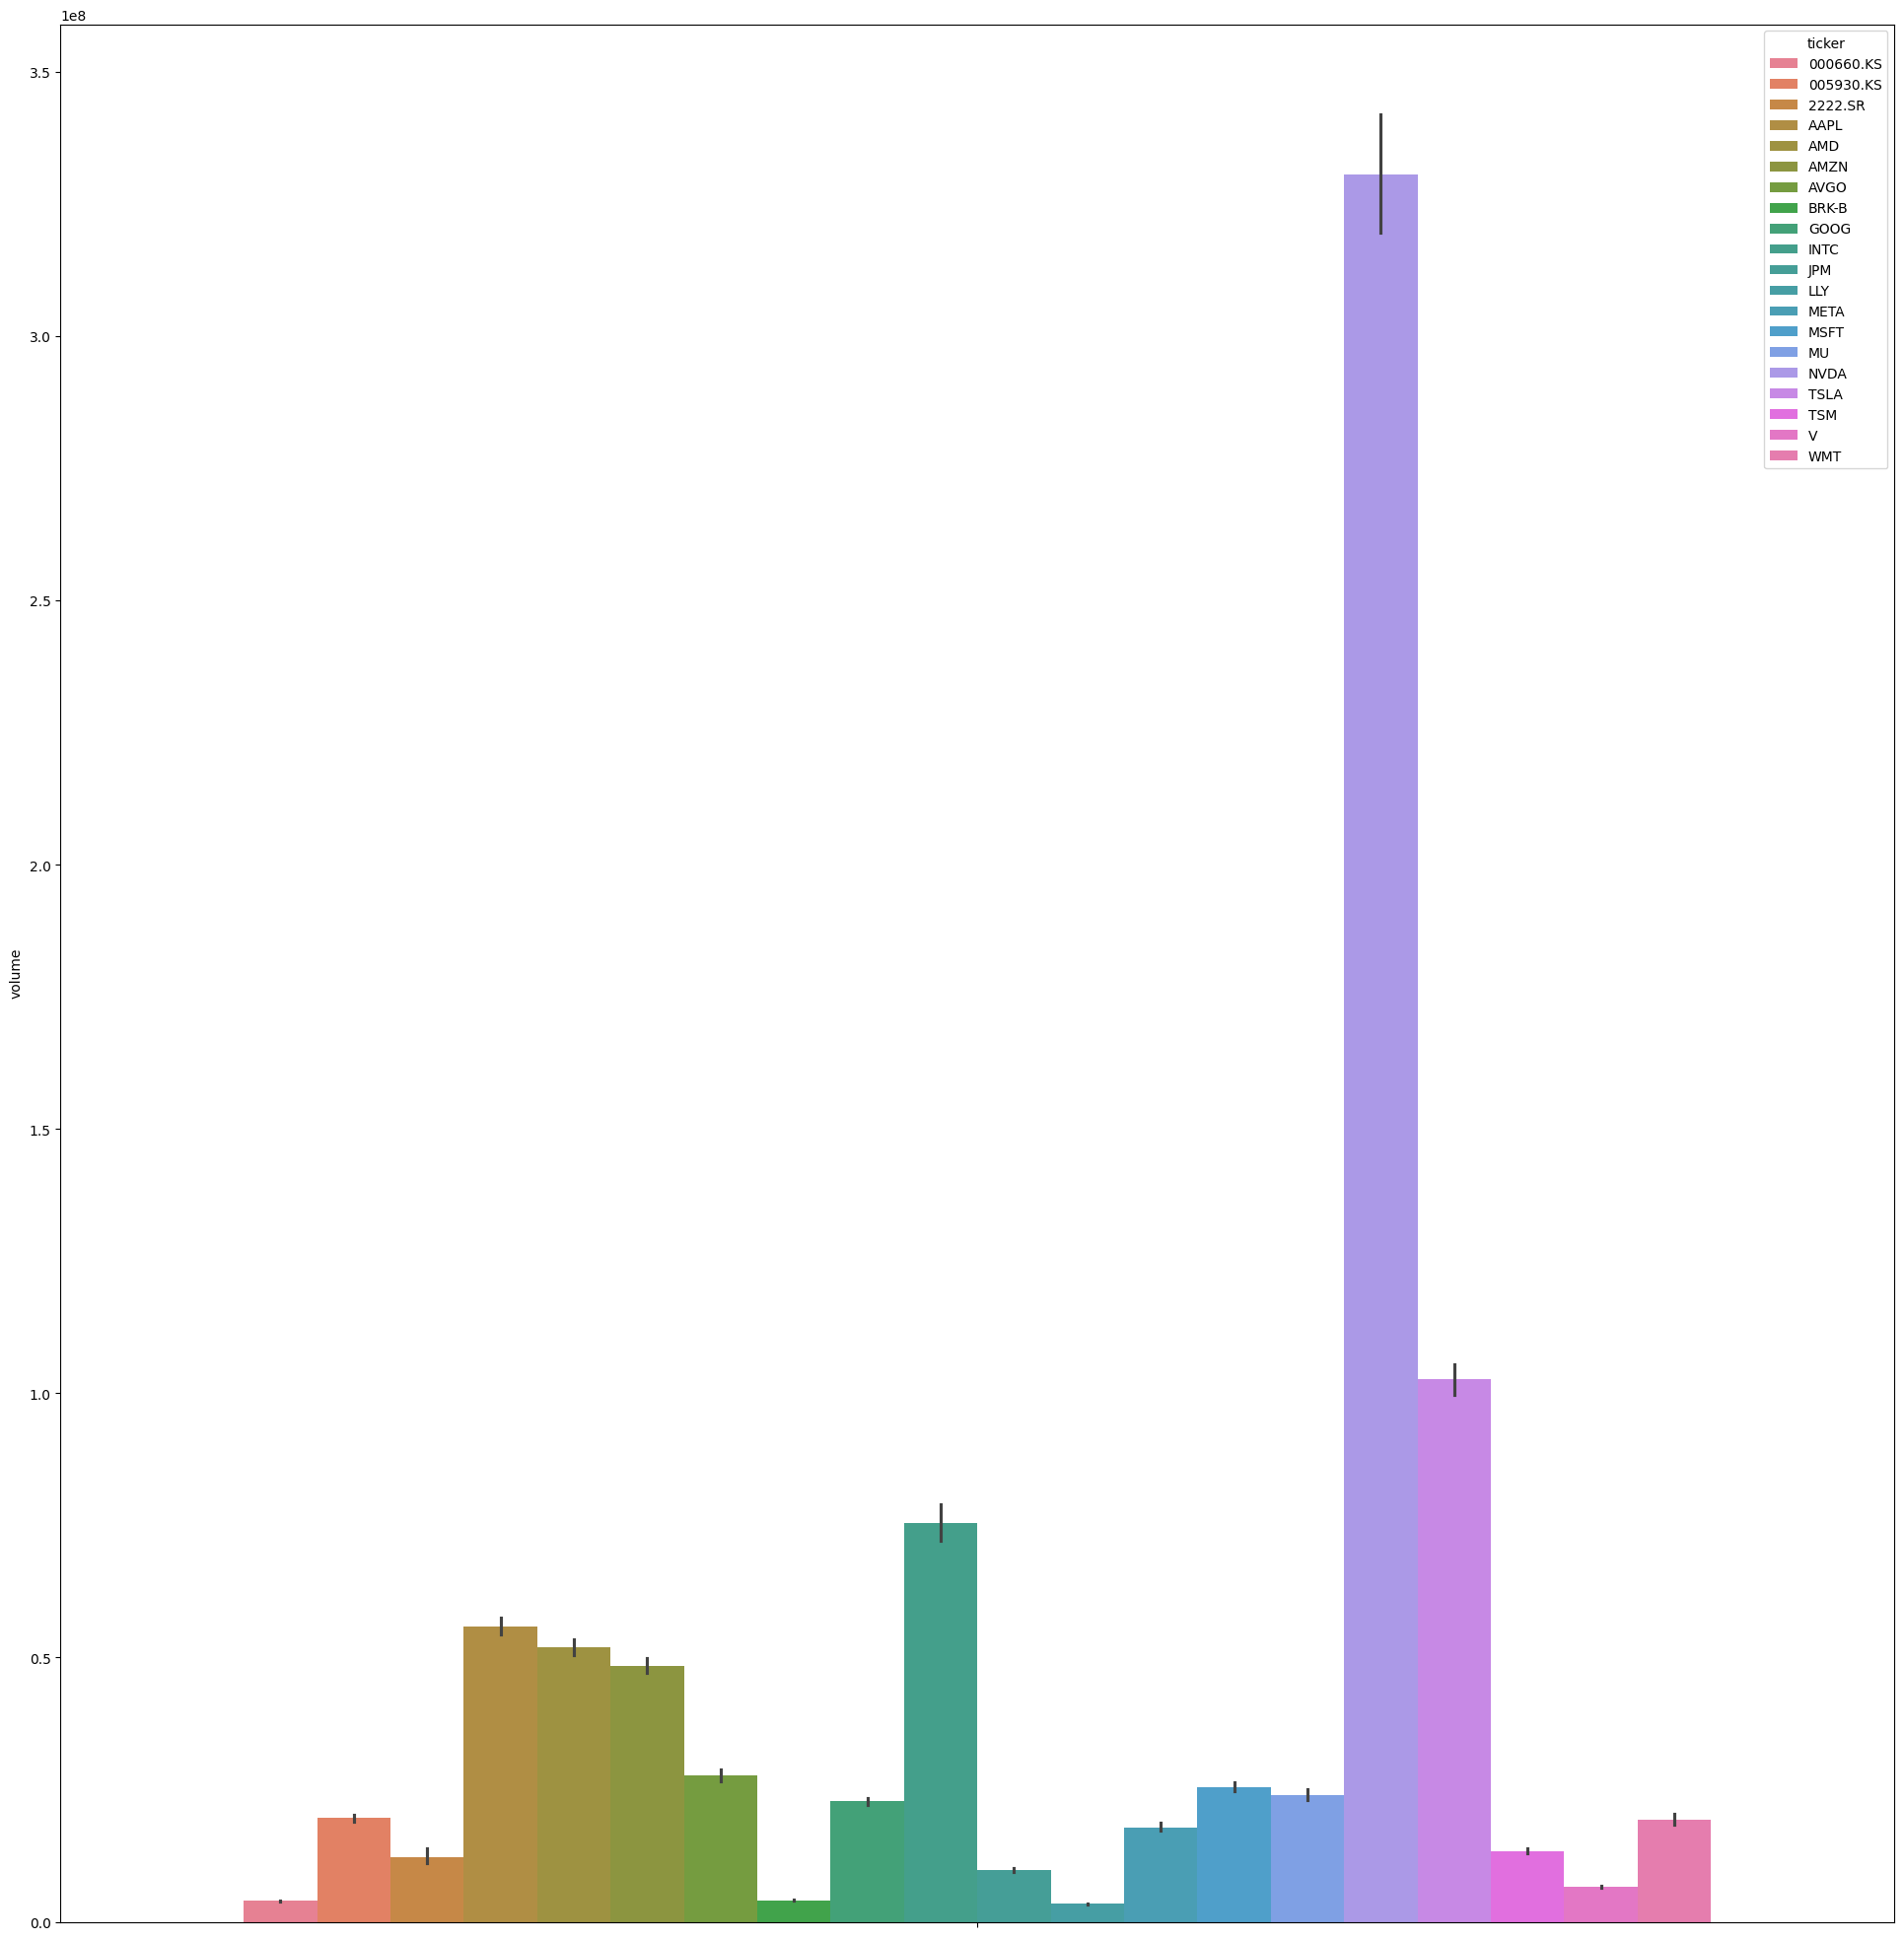

In [9]:
fig, ax = plt.subplots(figsize=(24, 25))
sns.barplot(
    data=prices,
    y="volume",
    hue="ticker"
)
plt.show()

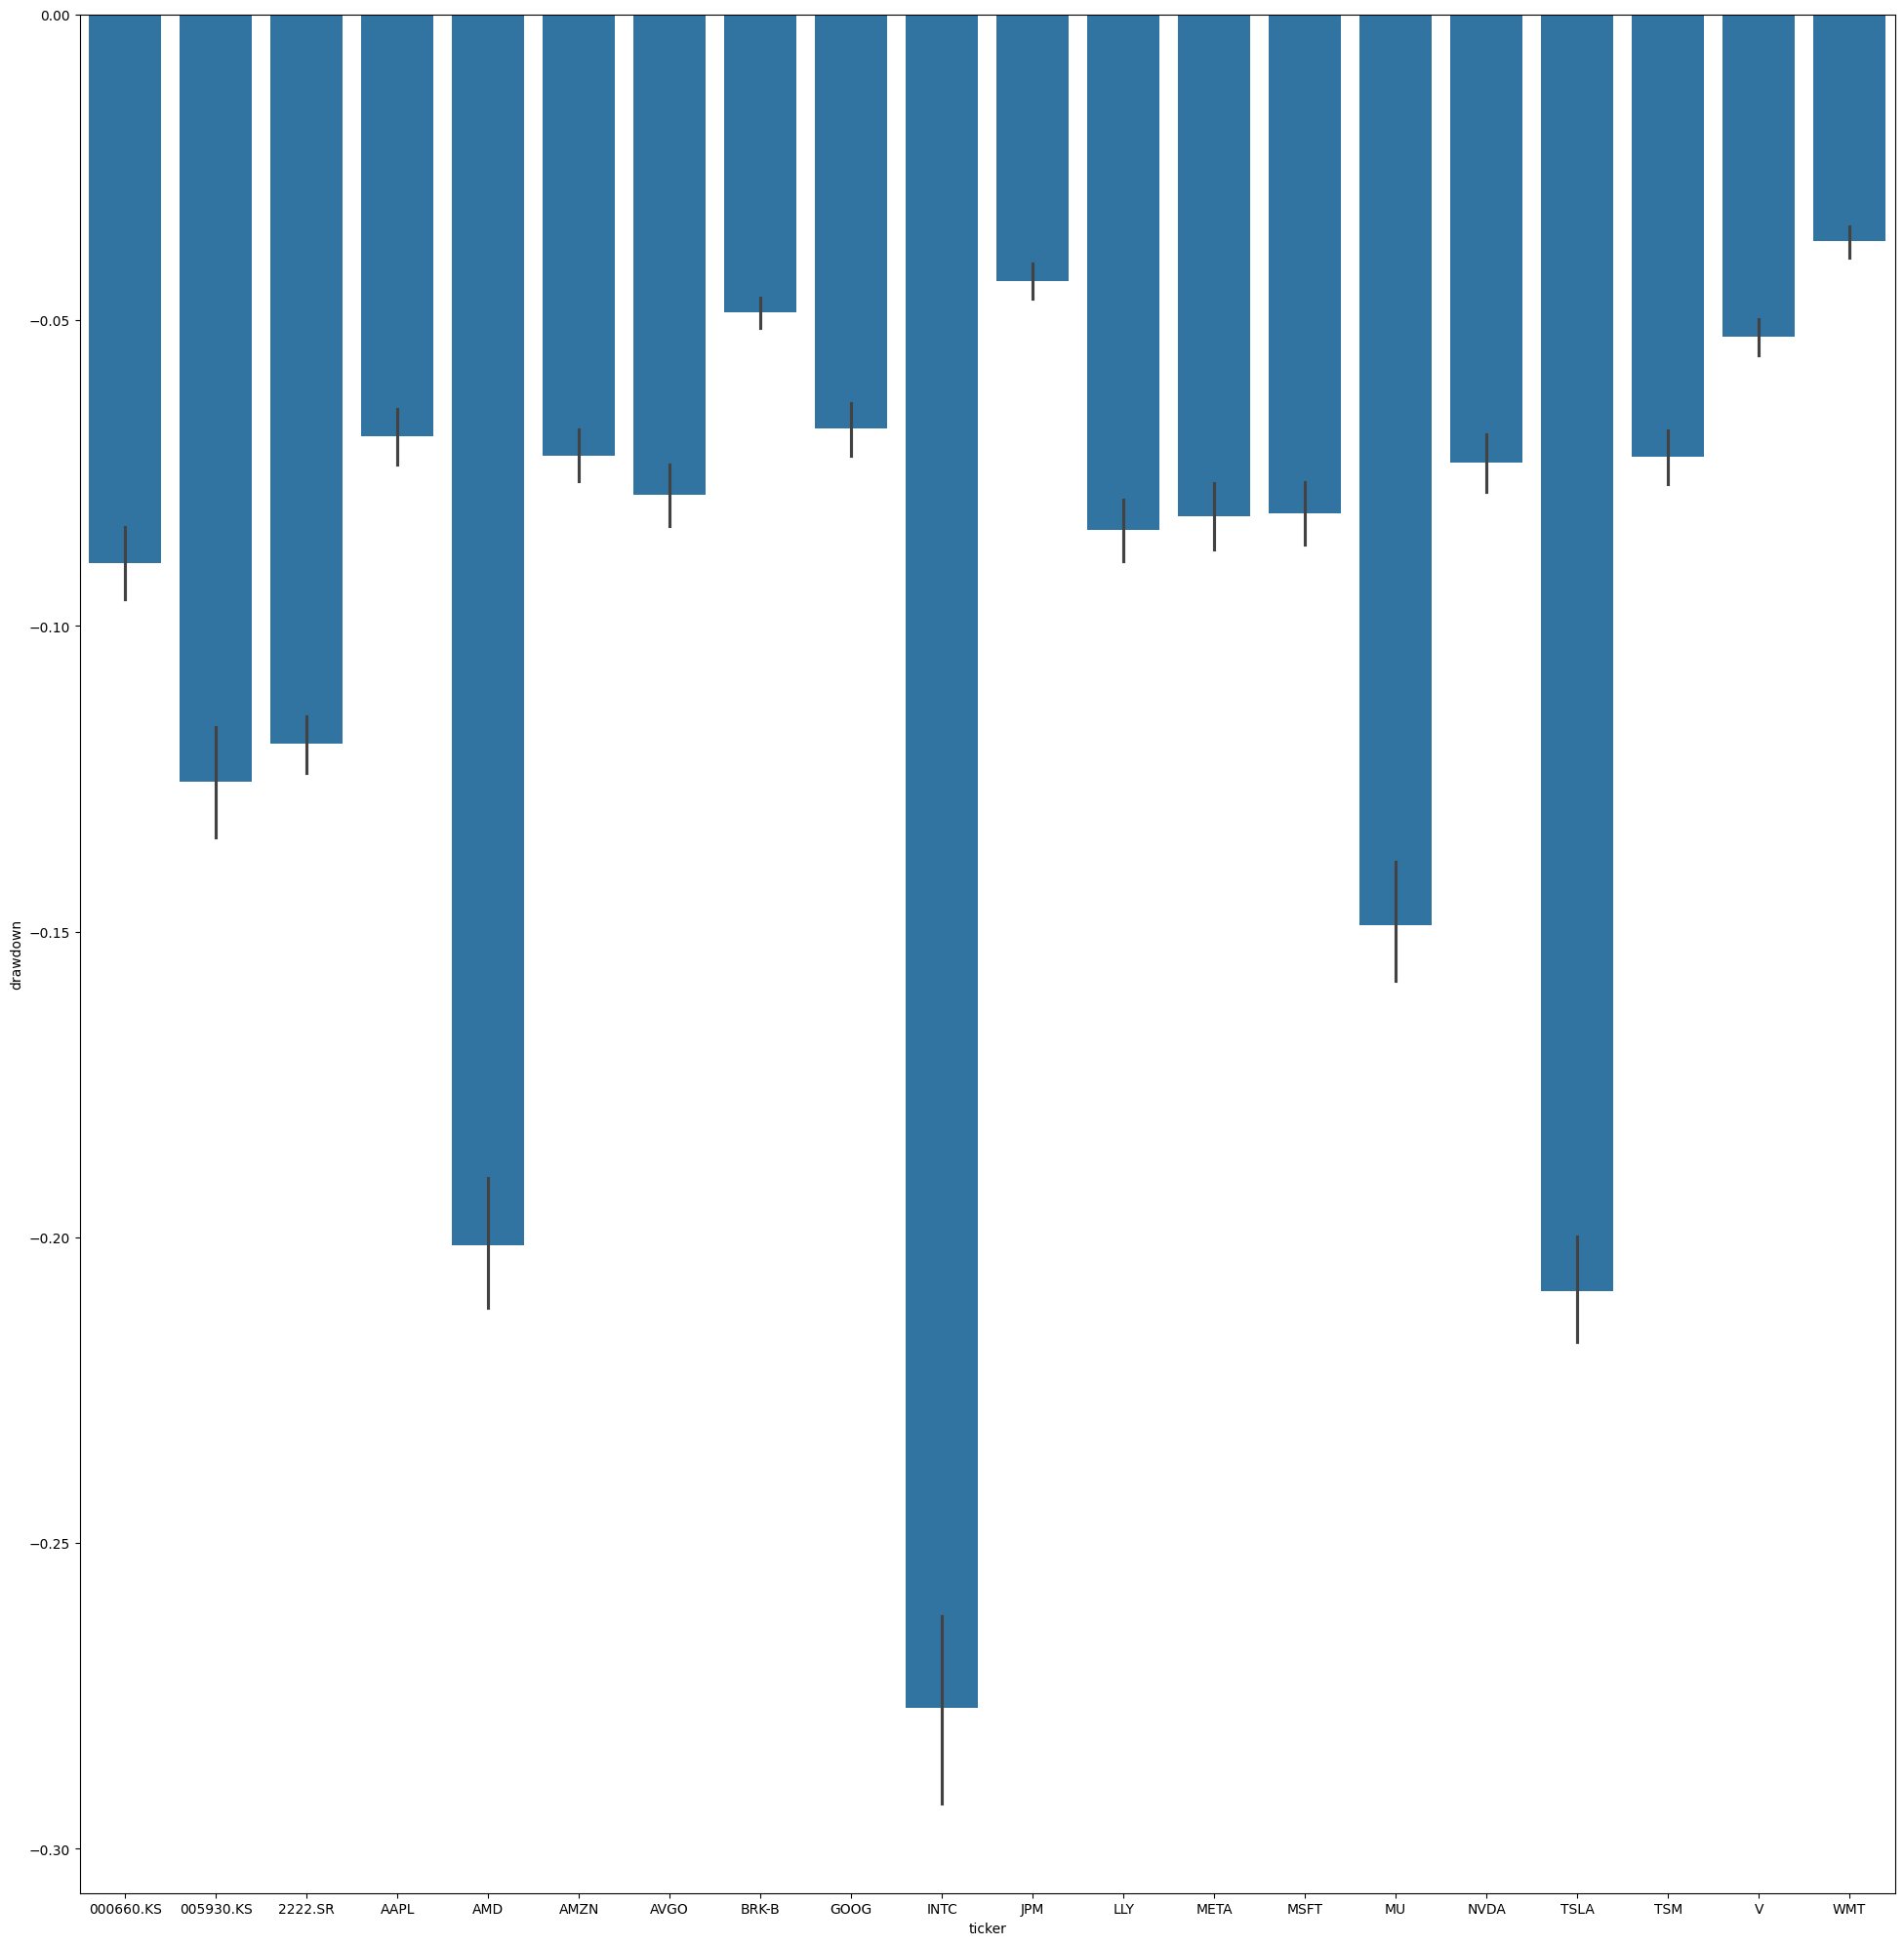

In [10]:
fig, ax = plt.subplots(figsize=(24, 25))
sns.barplot(
    data=prices,
    x="ticker",
    y="drawdown"
)
plt.show()

## 7. Risk versus Return

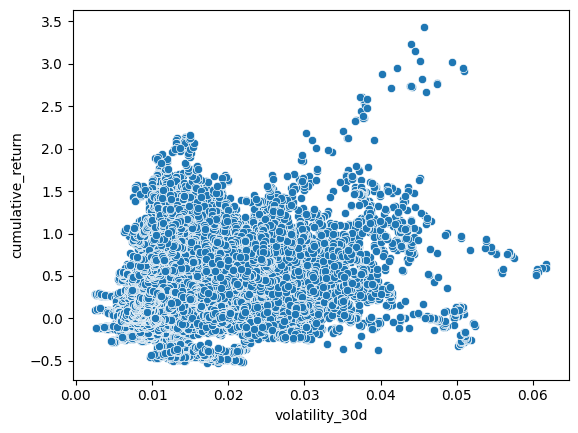

In [11]:
sns.scatterplot(
    data=prices,
    x="volatility_30d",
    y="cumulative_return",
)
plt.show()

## 8. Correlation Heatmap

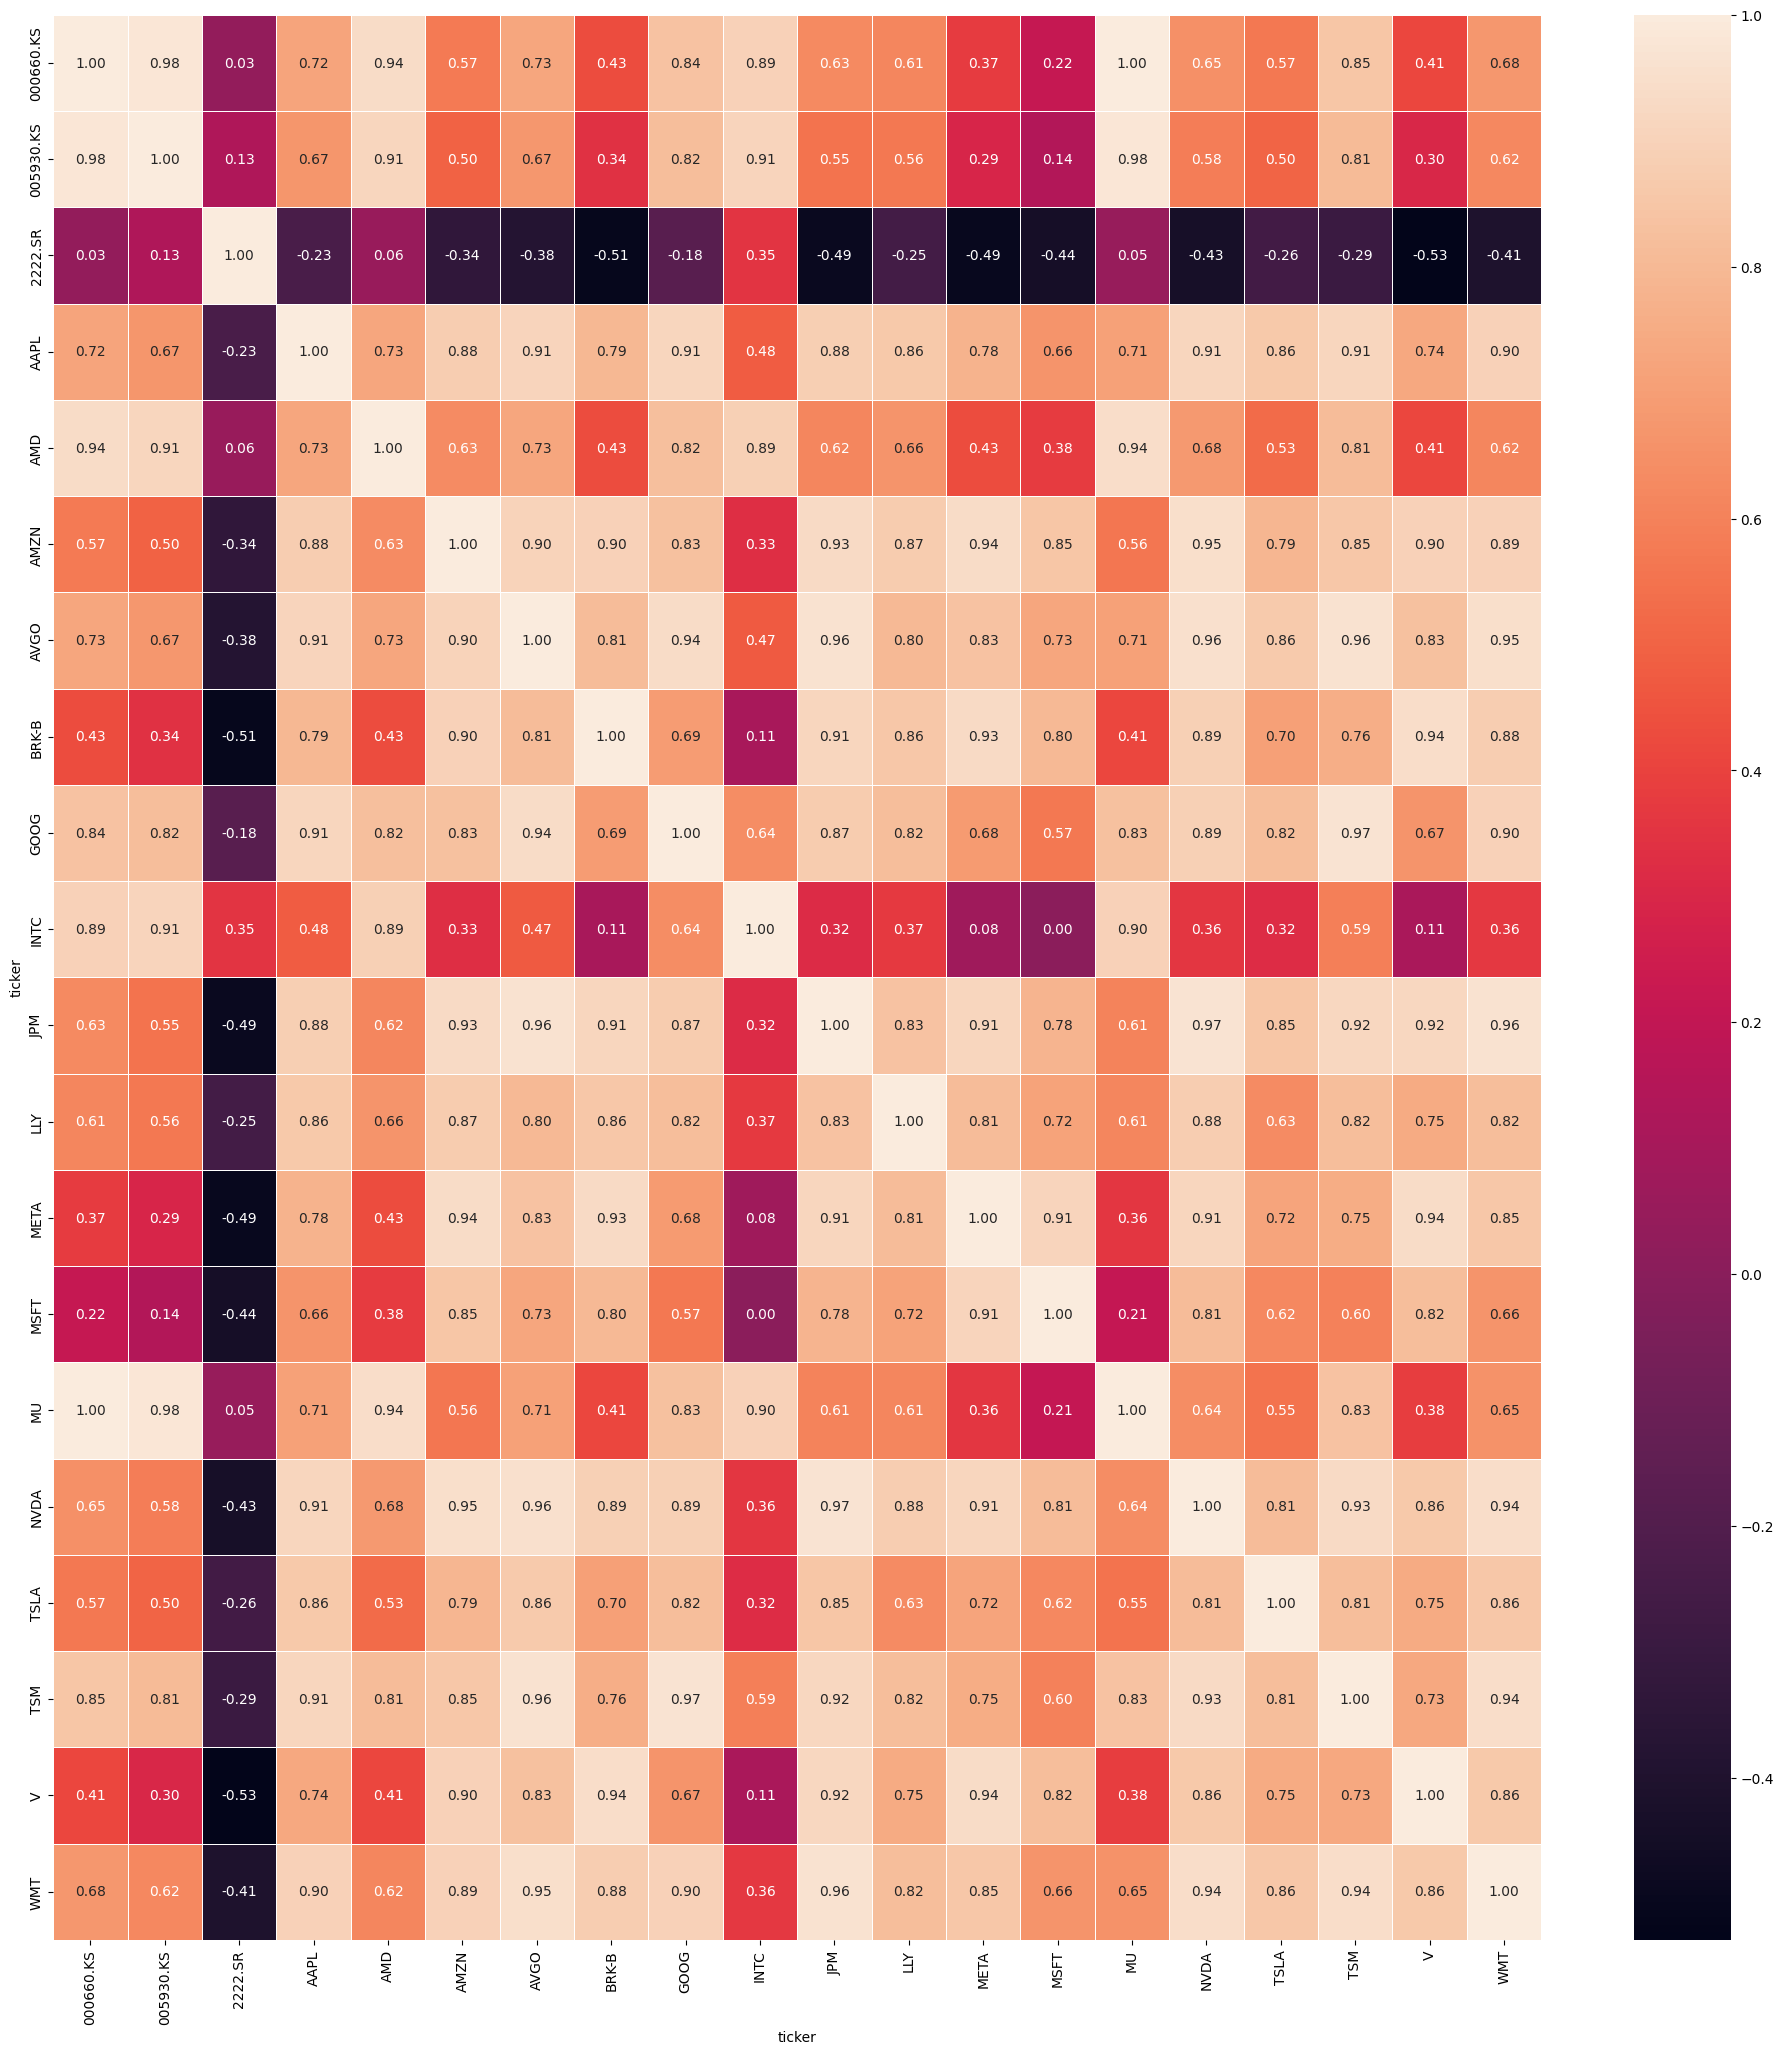

In [12]:
def check_correlation(df):
    fig, ax = plt.subplots(figsize=(24, 25))
    corr_matrix = df.corr()
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", linewidth=0.5)
    plt.show()

check_correlation(pivot_prices)

# 9. Business summary table

In [13]:
def summary_table(df):
    summary = (
        df.groupby("ticker")
        .agg(
            total_return=("cumulative_return", "last"),
            avg_volatility=("volatility_30d", "mean"),
            return_to_volatility_ratio=("daily_return", lambda x: x.mean() / x.std() if x.std() != 0 else np.nan),
            drawdown=("drawdown", "min"),
            
        )
        .reset_index()
    )
    return summary

In [ ]:
def overall_assessment(row, df):
    median_return = df["total_return"].median()
    median_volatility = df["avg_volatility"].median()

    if (row["total_return"] >= median_return and row["avg_volatility"] >= median_volatility):
        return "High Return / High Risk"

    if (row["total_return"] >= median_return and row["avg_volatility"] < median_volatility):
        return "Efficient Performer"

    if (row["total_return"] < median_return and row["avg_volatility"] < median_volatility):
        return "Stable"

    return "Weak Risk-Reward"

In [15]:
summary = summary_table(prices)

In [ ]:
summary["overall_assessment"] = summary.apply(
    overall_assessment,
    axis=1,
    df=summary
)

In [17]:
summary["total_return"] = (
    summary["total_return"] * 100
).round(2).astype(str) + "%"

summary["avg_volatility"] = (
    summary["avg_volatility"] * 100
).round(2).astype(str) + "%"

summary["drawdown"] = (
    summary["drawdown"] * 100
).round(2).astype(str) + "%"

summary["return_to_volatility_ratio"] = (
    summary["return_to_volatility_ratio"]
).round(2)

### Business Question

Which assets delivered the highest return-adjusted performance over the observation period?

In [18]:
summary

,ticker,total_return,avg_volatility,return_to_volatility_ratio,drawdown,overall_assessment
0,000660.KS,266.7%,2.28%,0.07,-36.6%,Strong Performer
1,005930.KS,-4.69%,1.63%,0.01,-42.85%,Stable
2,2222.SR,-10.16%,0.75%,-0.01,-25.56%,Stable
3,AAPL,162.13%,1.25%,0.09,-33.36%,Strong Performer
4,AMD,81.65%,2.6%,0.04,-63.0%,Strong Performer
5,AMZN,42.71%,1.48%,0.03,-30.88%,Strong Performer
6,AVGO,12.01%,2.17%,0.02,-41.15%,Stable
7,BRK-B,2.81%,0.85%,0.01,-14.95%,Stable
8,GOOG,215.93%,1.43%,0.10,-29.35%,Strong Performer
9,INTC,110.9%,2.57%,0.04,-63.8%,Strong Performer


During the analysed period, NVIDIA delivered the strongest cumulative return but also exhibited the highest volatility and deepest drawdowns. Microsoft achieved comparatively strong returns with lower risk, while SPY remained the most stable asset, exhibiting the lowest average volatility and relatively shallow maximum drawdowns throughout the observation period. Overall, the engineered financial indicators successfully distinguished between growth-oriented and defensive assets and provided a richer basis for portfolio analysis than raw closing prices alone.